# Negative Trolley Counts

Quantifies the negative values present in the raw HSE TrolleyGAR scrape, before the `abs()` cleaning applied in `02_preprocess.py`.

A negative count of patients on trolleys is physically impossible, so these are data-entry artifacts in the source report. This notebook lists every affected hospital and date, and summarises how many there are, where they occur, and how large they are.

Input: `output/01_daily_by_hospital_raw.csv` (the raw scrape).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

RAW = 'output/01_daily_by_hospital_raw.csv'
COUNT_COLUMNS = ['ED Trolleys', 'Ward Trolleys', 'Total']

raw = pd.read_csv(RAW, dtype=str)
# drop the report's own '<Region> Total' / 'National Total' summary rows
raw = raw[~raw['Hospital'].str.endswith('Total')].copy()
raw['date'] = pd.to_datetime(raw['Date'], format='%d/%m/%Y')
for c in COUNT_COLUMNS:
    raw[c] = pd.to_numeric(raw[c], errors='coerce')
raw.shape

Matplotlib is building the font cache; this may take a moment.


(45637, 10)

## Every negative value (hospital, date, column)

One row per negative cell in the raw data.

In [2]:
neg = (
    raw.melt(id_vars=['date', 'Hospital'], value_vars=COUNT_COLUMNS,
             var_name='metric', value_name='value')
    .dropna(subset=['value'])
)
neg = neg[neg['value'] < 0].sort_values(['date', 'Hospital']).reset_index(drop=True)
neg['date'] = neg['date'].dt.strftime('%d/%m/%Y')
print(f'{len(neg)} negative values in total')
neg

93 negative values in total


,date,Hospital,metric,value
0,03/01/2023,Portiuncula University Hospital,ED Trolleys,-6.0
1,04/01/2023,Portiuncula University Hospital,ED Trolleys,-6.0
2,05/01/2023,Portiuncula University Hospital,ED Trolleys,-5.0
3,07/01/2023,Our Lady's Hospital Navan,ED Trolleys,-16.0
4,07/01/2023,Portiuncula University Hospital,ED Trolleys,-4.0
...,...,...,...,...
88,05/10/2024,Portiuncula University Hospital,ED Trolleys,-1.0
89,11/10/2024,Sligo University Hospital,ED Trolleys,-2.0
90,08/12/2024,Mayo University Hospital,ED Trolleys,-2.0
91,01/03/2025,Tipperary University Hospital,ED Trolleys,-1.0


## How many, and where

Counts by hospital, by metric, and by year.

In [3]:
print('By metric:')
print(neg['metric'].value_counts().to_string())

print('\nBy hospital:')
print(neg['Hospital'].value_counts().to_string())

print('\nBy year:')
print(pd.to_datetime(neg['date'], format='%d/%m/%Y').dt.year.value_counts().sort_index().to_string())

By metric:
metric
ED Trolleys    93

By hospital:
Hospital
Cavan General Hospital                 20
Our Lady of Lourdes Hospital           14
Portiuncula University Hospital        13
CHI at Temple Street                   12
Wexford General Hospital               10
Sligo University Hospital               5
Naas General Hospital                   4
Letterkenny University Hospital         4
Our Lady's Hospital Navan               3
Mayo University Hospital                3
St Luke's General Hospital Kilkenny     2
MRH Portlaoise                          1
Connolly Hospital                       1
Tipperary University Hospital           1

By year:
date
2023    84
2024     7
2025     2


## Magnitude

How large are the negatives, and how do they compare to the size of the counts overall? (Each is a single hospital on a single day.)

In [4]:
print('Negative-value magnitude (abs):')
print(neg['value'].abs().describe().to_string())

total_cells = raw[COUNT_COLUMNS].notna().sum().sum()
print(f'\n{len(neg)} negatives out of {total_cells:,} reported count cells ({100 * len(neg) / total_cells:.3f}%)')

Negative-value magnitude (abs):
count    93.000000
mean      2.279570
std       2.481959
min       1.000000
25%       1.000000
50%       1.000000
75%       2.000000
max      16.000000

93 negatives out of 99,444 reported count cells (0.094%)


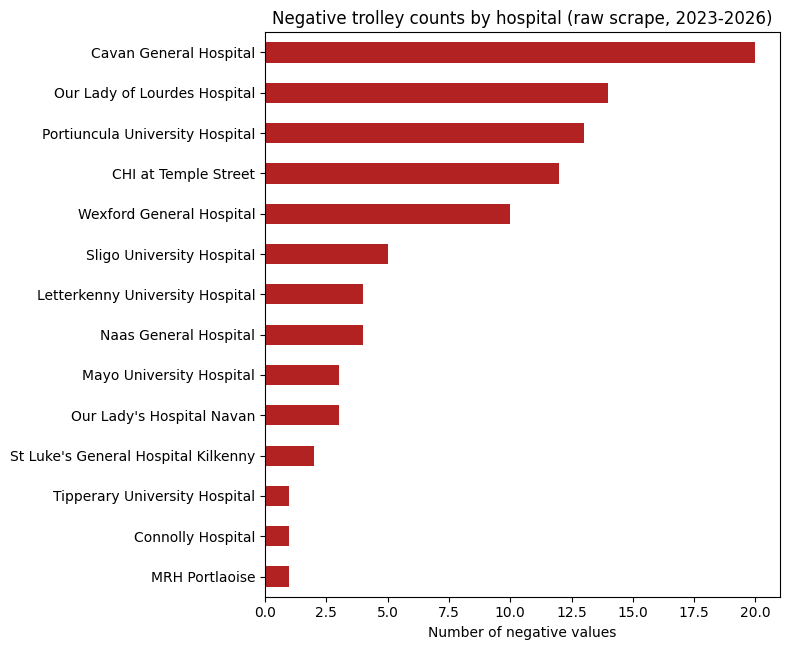

In [5]:
by_hosp = neg['Hospital'].value_counts()
fig, ax = plt.subplots(figsize=(8, 0.4 * len(by_hosp) + 1))
by_hosp.sort_values().plot.barh(ax=ax, color='firebrick')
ax.set_xlabel('Number of negative values')
ax.set_ylabel('')
ax.set_title('Negative trolley counts by hospital (raw scrape, 2023-2026)')
plt.tight_layout()
plt.show()

## Verified against the live source HTML

A sample of the negatives was checked directly against the HSE TrolleyGAR page for that date (not via the scraped CSV), confirming the negative is in the source itself, not a scraping artifact. Every case spans a different hospital and year; values read straight off the page:

| Date | Hospital | ED | Ward | Total |
|------|----------|----|------|-------|
| 03/01/2023 | Portiuncula University Hospital | -6 | 16 | 10 |
| 07/01/2023 | Our Lady's Hospital Navan | -16 | 17 | 1 |
| 20/01/2023 | Cavan General Hospital | -1 | 1 | 0 |
| 19/02/2023 | Wexford General Hospital | -1 | 12 | 11 |
| 19/03/2023 | CHI at Temple Street | -1 | 11 | 10 |
| 09/07/2023 | Sligo University Hospital | -2 | 17 | 15 |
| 08/03/2024 | Letterkenny University Hospital | -1 | 1 | 0 |
| 01/03/2025 | Tipperary University Hospital | -1 | 2 | 1 |

The negatives appear only in the ED column, always paired with a Ward value so the reported Total nets out non-negative (e.g. ED -16 + Ward 17 = Total 1). The source encodes a same-day correction in the ED field; the Total is the reliable figure and is the response the pipeline aggregates. abs() only affects the ED component.